In [1]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxxx"
CHECKPOINT_FILE = "step_xxxx.pt"


# Changing Bases Using Eulerian Transforms

This section demonstrates the Eulerian change-of-basis formulation. The core idea is that we can define a continuous isometry (an orthogonal transformation) $Q(t)$ in function space governed by the following ordinary differential equation (ODE):

$$\dot{Q}(t) = \mathcal{K}(t) Q(t), \qquad Q(0) = I$$

Here, $\mathcal{K}(t)$ is a skew-symmetric operator that acts as the generator of the isometry. It is parameterised by two learnable components:

- $U(t, \cdot) \in \mathbb{R}^{N \times R \times C}$: a spatiotemporal neural field producing $R$ functions spanning an $R$-dimensional subspace of $\mathcal{H}$.
- $K_R(t) \in \mathbb{R}^{R \times R}$: a time-dependent matrix produced by a small MLP; skew-symmetrised as $A = K_R - K_R^\top$.

The generator is then:
$$\mathcal{K}(t) = U(t)\, A(t)\, U(t)^\ast$$

which is skew-symmetric by construction ($\mathcal{K}^\ast = -\mathcal{K}$). Each Euler step applies the Cayley map $(I - \mathcal{K}/2)^{-1}(I + \mathcal{K}/2)$ via a rank-$R$ Woodbury solve — an exact $\mathcal{H}$-isometry for any grid size.

In [2]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')
sys.path.append('..')  # for notebook_helpers in notebooks/

from notebook_helpers import field_to_img, to_rgb_image, visualize_generator_U

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Run the following code to create such an isometry:

In [3]:
%autoreload 2 
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.networks import NerfSpatioTemporalField, LatentBilinearSpatiotemporalField
import functools

GRID_SIZE = 32
N_TRUNCATION = 3

# manual seed for reproducibility
torch.manual_seed(0)
isometry = EulerianIsometry(
    coords_dim=2,
    channels_dim=1,
    gradient_checkpointing=True,
    base_acceleration=1000.0,
    rank=10,
    n_time_freqs=16,
    kr_hidden_dims=(64, 64),
    atom_shuffling_K=5,
    atom_selector_hidden_dims=(64, 64),

    scalar_field_partial=functools.partial(
        NerfSpatioTemporalField,    
        spatial_hidden_dims=[256, 256, 256],
        activation=torch.nn.SiLU,
        nerf_n_levels=8,
        nerf_n_base=64,
        nerf_freq_min=1.0,
        nerf_freq_max=64.0,
    ),
).to(device)


Next, run the transformation on a fixed grid and solve the ODE:

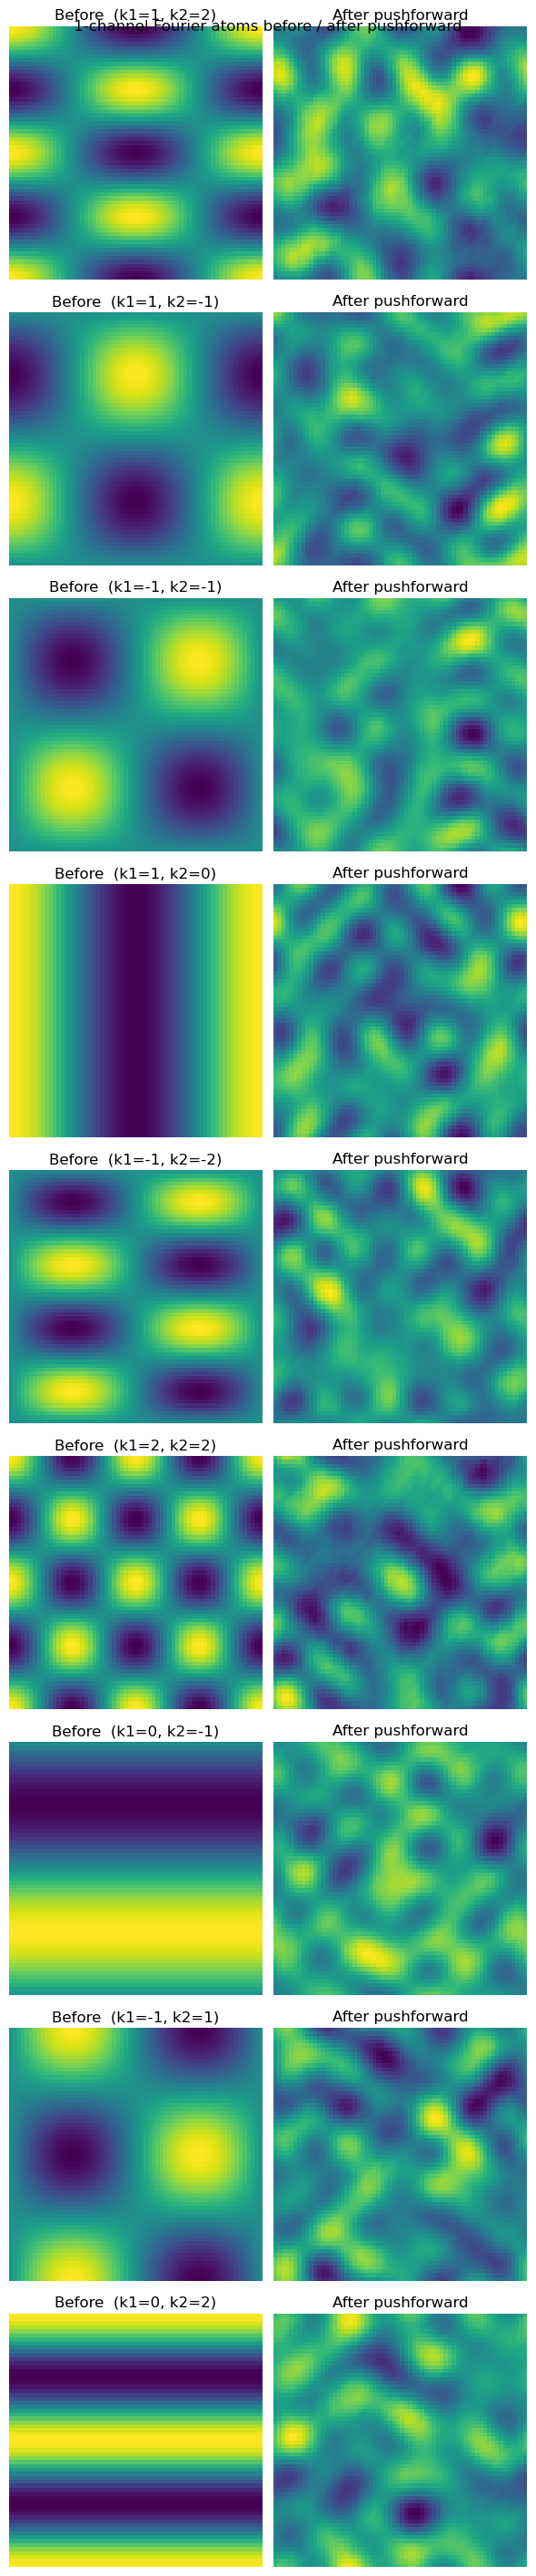

Atoms shown: 9/9


In [4]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

fourier_basis = FourierDictionary(domain_dim=2, num_channels=1, steepness=2.0, tiebreak_eps=1e-3)
torch.manual_seed(0)
indices_tensorized = fourier_basis.get_truncated_indices(N_TRUNCATION).to(device)
indices_tensorized = indices_tensorized[torch.randperm(indices_tensorized.shape[0])][:9]  # shuffle and take first 9
# indices_tensorized = indices_tensorized[-9:]  # shuffle and take first 9

N_per_dim = 64
end_time = 1.0

# Regular grid — no noise so we can reshape to (N, N) for imshow
xy = SquareSampler(stratified=True, add_noise=False).sample(N_per_dim).to(device)
src_field = fourier_basis.get_atoms(xy, indices_tensorized)
isometry.shuffle_model_state(20)
tgt_coords, _, tgt_field = isometry.pushforward(
    xy,
    torch.zeros(xy.shape[0], device=xy.device),
    src_field,
    start_time=0.0,
    end_time=end_time,
)

A = tgt_field.shape[0]
n_show = min(A, 9)
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3.2 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(field_to_img(src_field[i], N_per_dim), origin='lower')
    k1, k2, _ = indices_tensorized[i].tolist()
    axes[i, 0].set_title(f'Before  (k1={k1}, k2={k2})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(field_to_img(tgt_field[i], N_per_dim), origin='lower')
    axes[i, 1].set_title(f'After pushforward')
    axes[i, 1].axis('off')

plt.suptitle('1-channel Fourier atoms before / after pushforward')
plt.tight_layout()
plt.show()
print(f"Atoms shown: {n_show}/{A}")


Next, run pairwise inner products before and after the transformation; you should expect to see the same heatmaps as the transformation is by design an isometry:

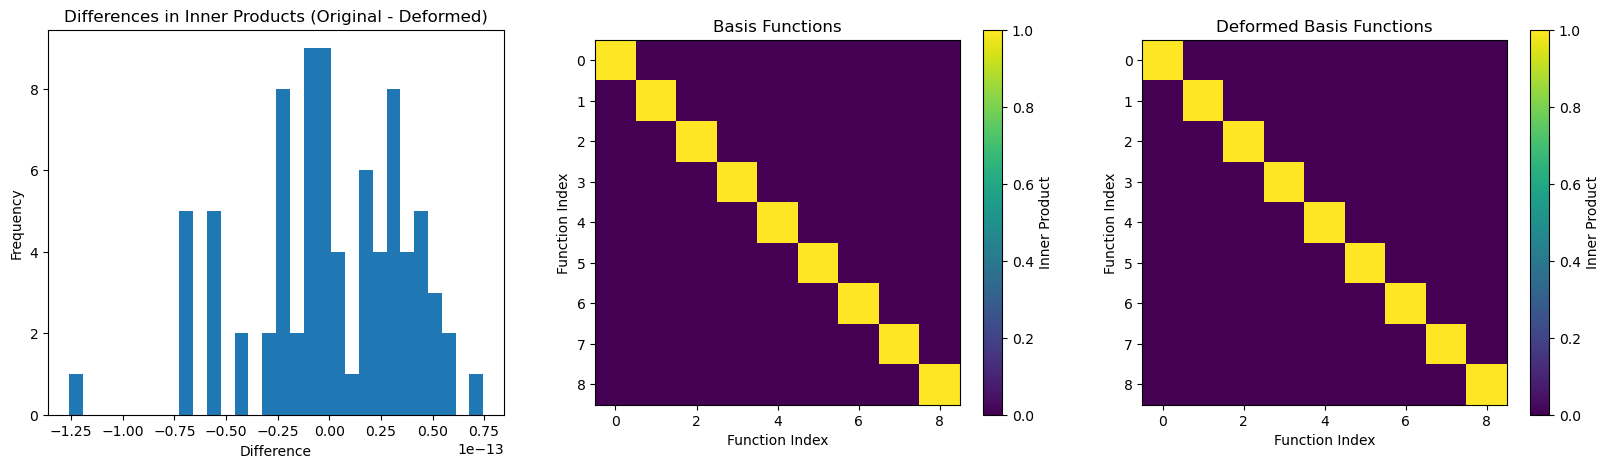

In [5]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product

# compute pairwise inner products
N = N_per_dim ** 2
inner_products = pairwise_inner_product(src_field, src_field)
inner_products_deformed = pairwise_inner_product(tgt_field, tgt_field)
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=3)
# heatmap of inner products
m = axes[2].imshow(inner_products_deformed.detach().cpu())
fig.colorbar(m, ax=axes[2], label='Inner Product')
axes[2].set_title('Deformed Basis Functions')
axes[2].set_xlabel('Function Index')
axes[2].set_ylabel('Function Index')

m = axes[1].imshow(inner_products.detach().cpu())
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten().detach().cpu(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


## Visualizing the Generator Field $U$ and Rotation $K_R$

The skew-adjoint generator $\mathcal{K}_\theta(t) = U_\theta(t)\,A_\theta(t)\,U_\theta(t)^\ast$ is controlled by $R$ spatial functions (the columns of $U$) and a time-dependent skew matrix $A = K_R - K_R^\top$. Below we visualise both on the unit square at several timesteps from $0$ to $1$:

- **Rows $0$ to $R-1$**: the $r$-th column $u_r(t, \cdot)$ of $U$, evaluated spatially over the unit square.
- **Row $R$**: the orthogonal matrix $\exp(K_R - K_R^\top)$ displayed as an $R \times R$ heatmap, representing the finite rotation generated by $K_R$ at each timestep.

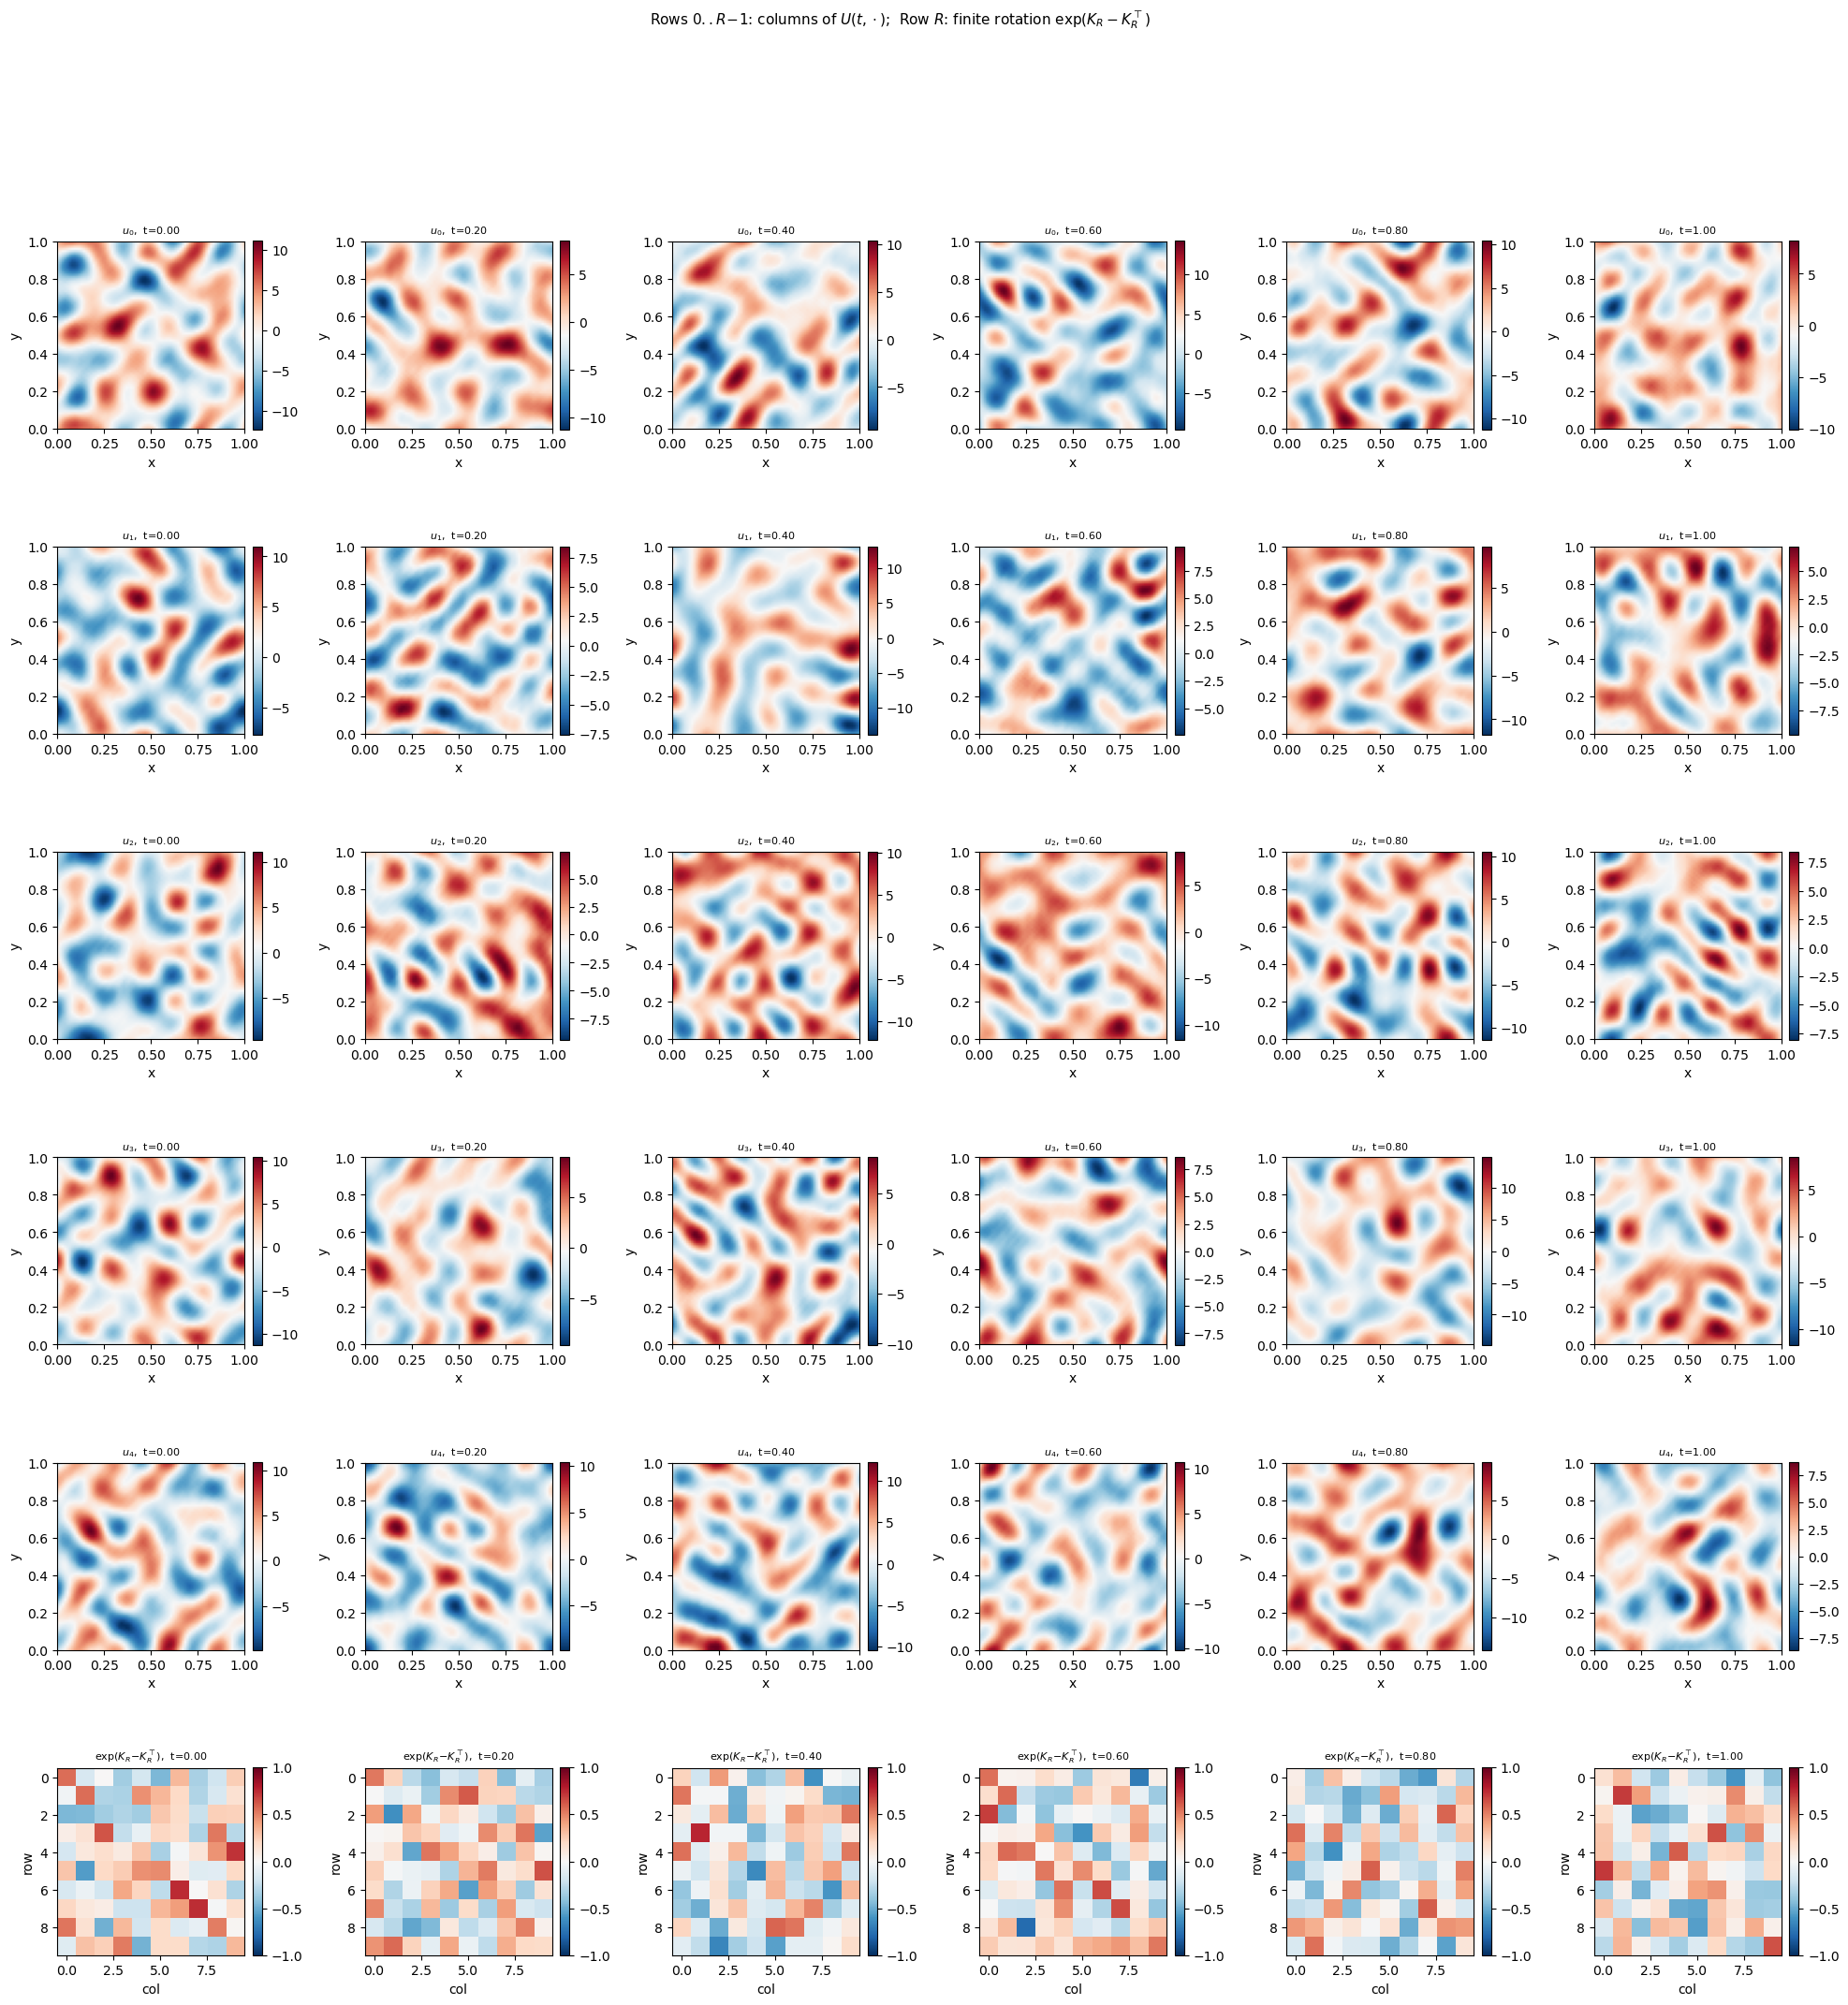

In [6]:
%autoreload 2
import torch
from infidictionary.domain_samplers import SquareSampler

timesteps = torch.linspace(0.0, 1.0, 6)
N_vis = 80
coords_vis = SquareSampler(stratified=True, add_noise=False).sample(N_vis).to(device)

visualize_generator_U(isometry, coords_vis, N_vis, timesteps, device)


The following code verifies the consistency of the pushforward and pullback operators. 
We can evaluate this consistency by testing if the following identity holds true:

$$Q_s^t Q_t^s f = (Q_t^s)^\ast Q_t^s f = f$$

Run the following which visualizes $f$, $Q_t^s f$, and $Q_s^t Q_t^s f$ and checks whether $f \approx Q_s^t Q_t^s f$:

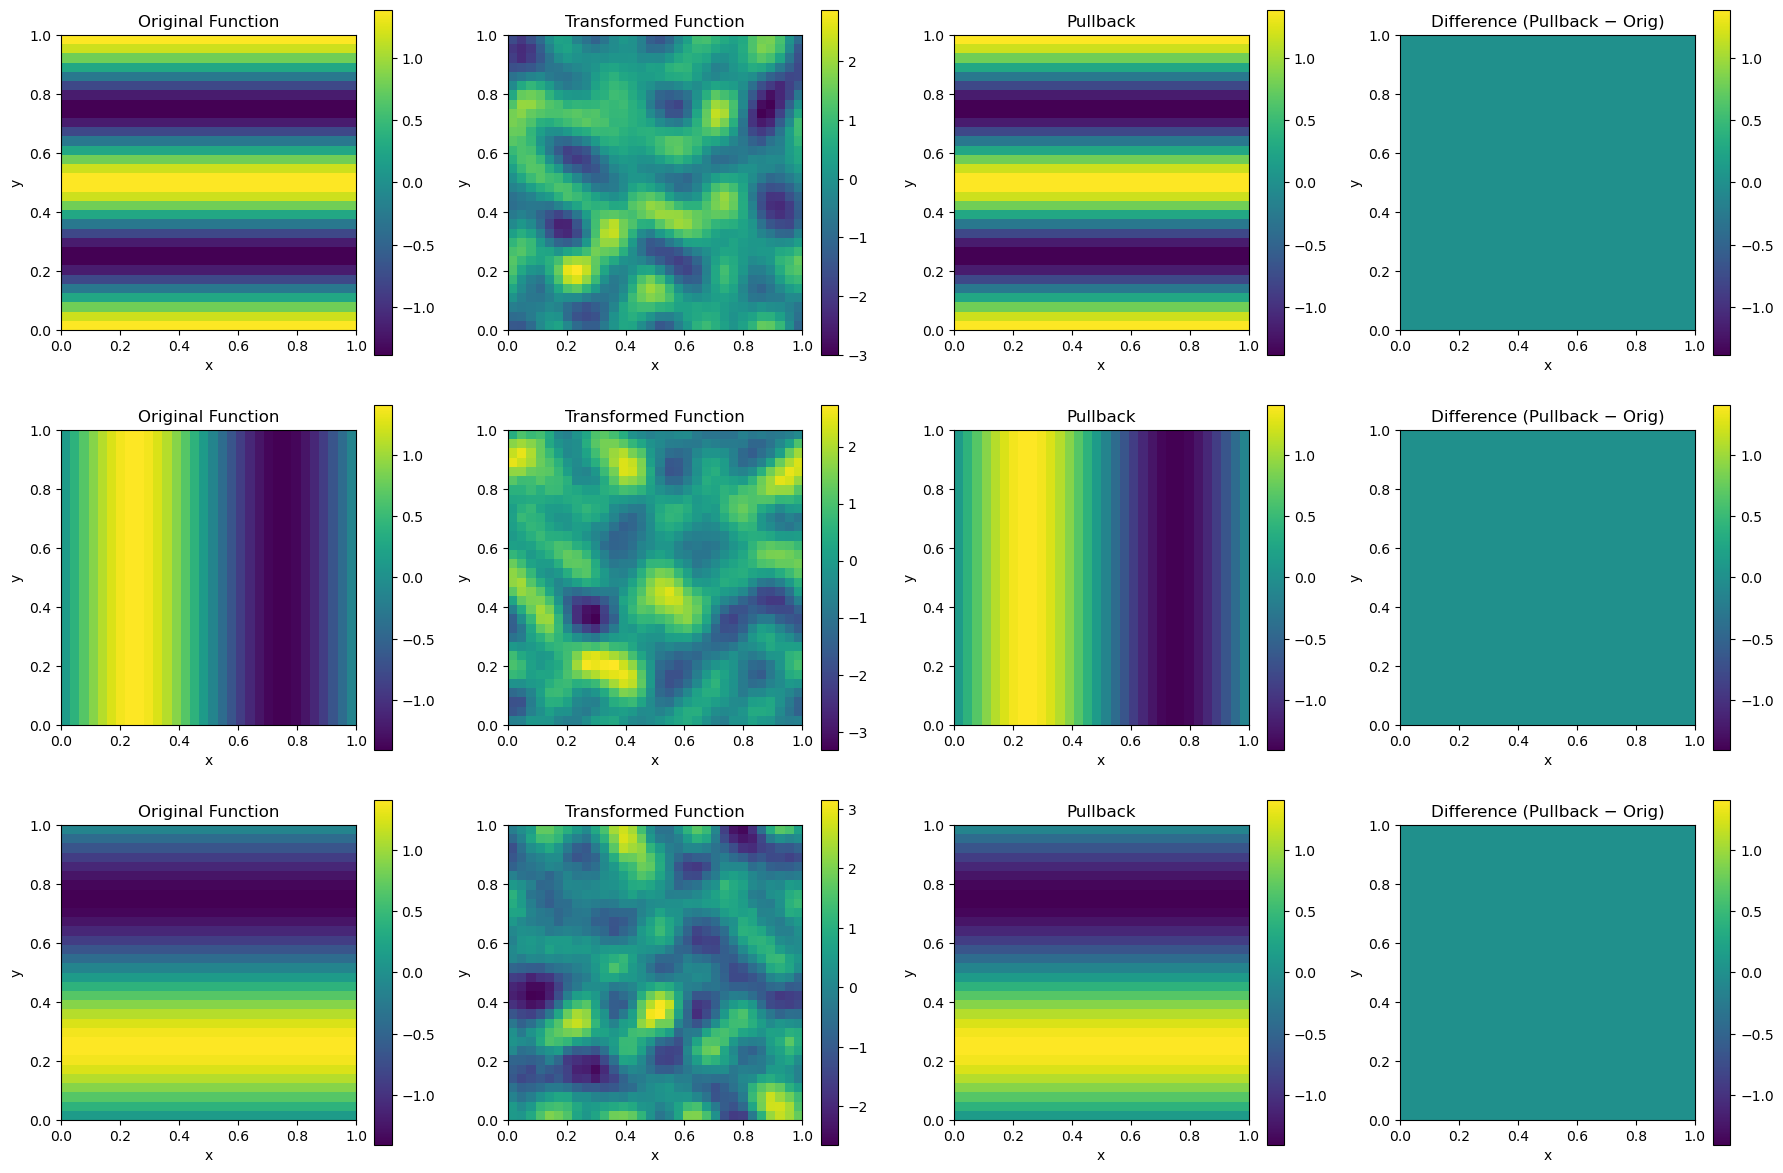

In [7]:
%autoreload 2
from infidictionary.domain_samplers import SquareSampler

start_time = 0.0
end_time = 5.0
N_per_dim = 32
inner_steps = 50

isometry.shuffle_model_state(inner_steps)
coords = SquareSampler(stratified=True, add_noise=False).sample(N_per_dim).to(device)
fourier_dictionary = FourierDictionary(domain_dim=2, num_channels=1, steepness=2.0, tiebreak_eps=1e-3)
f = fourier_dictionary.get_atoms(
    coords,
    torch.tensor([[0, 2, 0], [-1, 0, 0], [0, -1, 0]]).to(device),
).to(device)  # (3, N, 1)

coords, logabsdet, f_transformed = isometry.pushforward(
    coords,
    torch.zeros(coords.shape[0], device=coords.device),
    f,
    start_time=start_time,
    end_time=end_time,
)
coords, logabsdet, f_transformed_pullback = isometry.pullback(
    coords,
    logabsdet,
    f_transformed,
    start_time=start_time,
    end_time=end_time,
)

diff = f_transformed_pullback - f

fig, axes = plt.subplots(nrows=len(f), ncols=4, figsize=(18, 4 * len(f)))

for i in range(len(f)):
    vmin_f = f[i].min().item();  vmax_f = f[i].max().item()
    vmin_d = diff[i].min().item(); vmax_d = diff[i].max().item()
    vmin_all = min(vmin_f, vmin_d);  vmax_all = max(vmax_f, vmax_d)

    specs = [
        (f[i],                    'Original Function',          vmin_f,   vmax_f),
        (f_transformed[i],        'Transformed Function',       None,     None),
        (f_transformed_pullback[i], 'Pullback',                 vmin_f,   vmax_f),
        (diff[i],                 'Difference (Pullback − Orig)', vmin_all, vmax_all),
    ]
    for j, (field, title, vmin, vmax) in enumerate(specs):
        ax = axes[i, j]
        kw = dict(origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
        if vmin is not None:
            kw['vmin'] = vmin;  kw['vmax'] = vmax
        im = ax.imshow(field_to_img(field, N_per_dim), **kw)
        plt.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

plt.tight_layout()
plt.show()


---
## Multichannel (C = 3) Eulerian Isometry

Repeat every check above with `channels_dim=3`.  Each Fourier atom lives in one of three output channels — atoms are vectors in $L^2([0,1]^2, \mathbb{R}^3)$.  An isometry must preserve the full $\mathbb{R}^3$-valued inner product
$$\langle f, g \rangle = \frac{1}{N}\sum_n e^{\lambda_n}\, f(x_n) \cdot g(x_n)$$
where the dot is the $\mathbb{R}^3$ inner product.  Cross-channel mixing (a deformed atom at $(k_1,k_2,c)$ gaining components in channels $c' \neq c$) is **expected and correct**.

In [8]:
%autoreload 2
from infidictionary.neural_isometries import EulerianIsometry
from infidictionary.networks import NerfSpatioTemporalField
import functools

# ── 3-channel isometry ────────────────────────────────────────────────────────
GRID_SIZE = 32
N_TRUNCATION = 5
torch.manual_seed(42)

isometry_3ch = EulerianIsometry(
    coords_dim=2,
    channels_dim=3,
    gradient_checkpointing=True,
    base_acceleration=100.0,
    rank=10,
    n_time_freqs=16,
    kr_hidden_dims=(64, 64),
    atom_shuffling_K=N_TRUNCATION,
    atom_selector_hidden_dims=(64, 64),
    scalar_field_partial=functools.partial(
        NerfSpatioTemporalField,
        spatial_hidden_dims=[256, 256, 256],
        activation=torch.nn.SiLU,
        nerf_n_levels=8,
        nerf_n_base=64,
        nerf_freq_min=1.0,
        nerf_freq_max=64.0,
    ),
).to(device)

### Step 1 — Pushforward of 3-channel Fourier atoms

Each atom $(k_1, k_2, c)$ is nonzero only in channel $c$ initially.  After pushforward the atom can gain energy in all three channels — visualised as an RGB image where each colour channel is independently rescaled to $[0,1]$.

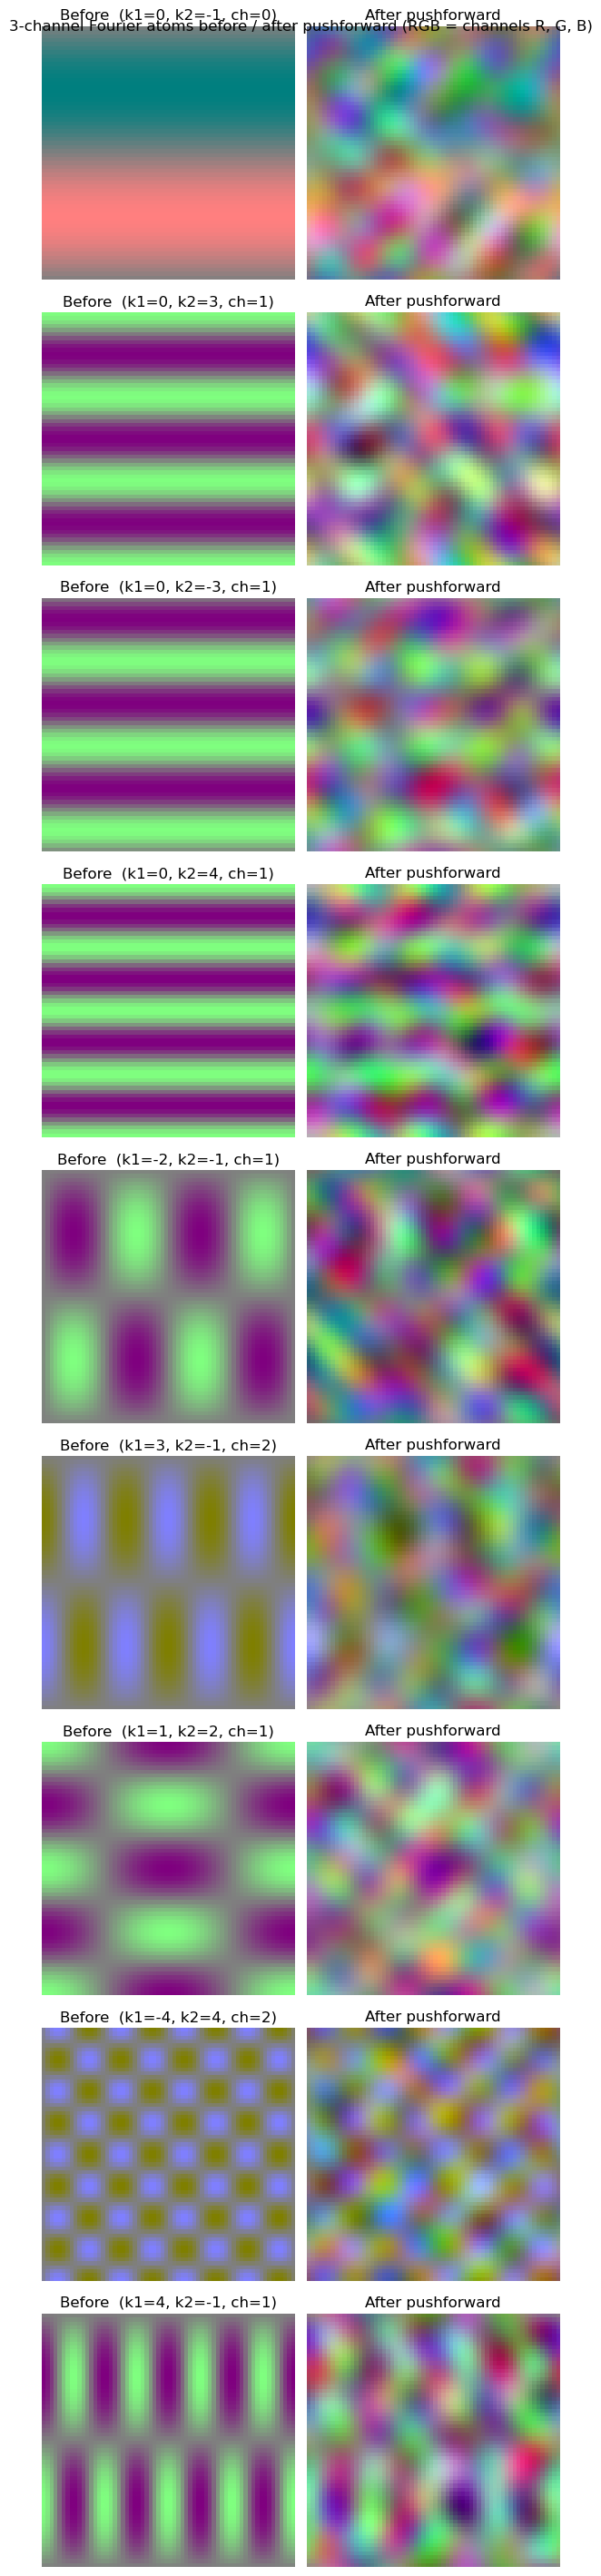

Atoms shown: 9/9


In [9]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

fourier_basis_3ch = FourierDictionary(domain_dim=2, num_channels=3, steepness=2.0, tiebreak_eps=1e-3)
# 3-channel atoms: indices are (k1, k2, channel)
indices_3ch = fourier_basis_3ch.get_truncated_indices(N_TRUNCATION).to(device)  # (A, 3)
torch.manual_seed(33)
indices_3ch = indices_3ch[torch.randperm(indices_3ch.shape[0])[:9]]  # get a subset of size 9 for visualization

N_per_dim_3ch = 64
coords_3ch = SquareSampler(stratified=True, add_noise=False).sample(N_per_dim_3ch).to(device)          # (N, 2)
atoms_3ch   = fourier_basis_3ch.get_atoms(coords_3ch, indices_3ch)     # (A, N, 3)

isometry_3ch.shuffle_model_state(20)
_, _, atoms_3ch_pushed = isometry_3ch.pushforward(
    coords_3ch,
    torch.zeros(coords_3ch.shape[0], device=device),
    atoms_3ch,
    start_time=0.0,
    end_time=1.0,
)  # (A, N, 3)

A = atoms_3ch.shape[0]
n_show = min(A, 9)
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3.2 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(to_rgb_image(atoms_3ch[i], N_per_dim_3ch), origin='lower')
    k1, k2, ch = indices_3ch[i].tolist()
    axes[i, 0].set_title(f'Before  (k1={k1}, k2={k2}, ch={ch})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(to_rgb_image(atoms_3ch_pushed[i], N_per_dim_3ch), origin='lower')
    axes[i, 1].set_title(f'After pushforward')
    axes[i, 1].axis('off')

plt.suptitle('3-channel Fourier atoms before / after pushforward (RGB = channels R, G, B)')
plt.tight_layout()
plt.show()
print(f"Atoms shown: {n_show}/{A}")


### Step 2 — Gram matrix isometry check

The Gram matrix $G_{ab} = \langle Q_\theta\psi_a,\, Q_\theta\psi_b \rangle$ should equal the identity for an exact isometry.  The initial atoms already satisfy $G \approx I$ up to quadrature error; after pushforward it should remain just as close.

                               ||G − I||_F      / √A    max|G−I|
Initial atoms                       0.0000    0.0000      0.0000
Pushed atoms  (Q_θψ)                0.0000    0.0000      0.0000


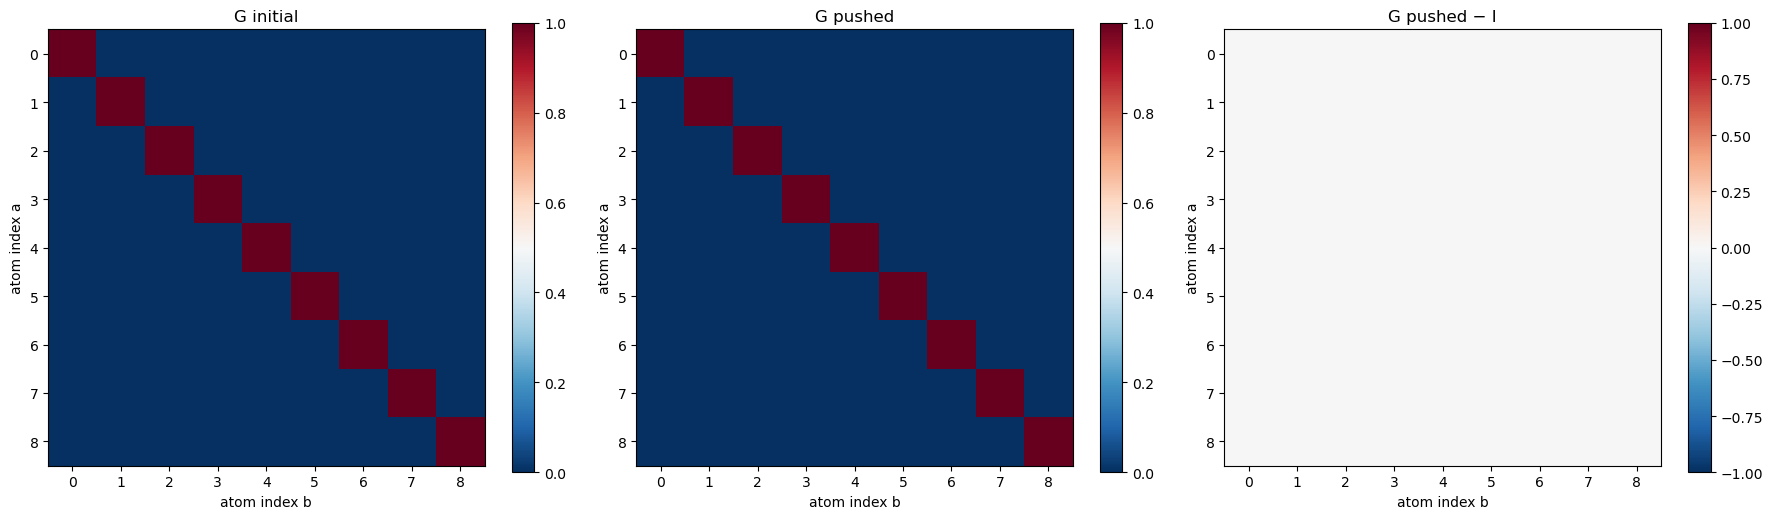

In [10]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product

logabsdet_3ch = torch.zeros(coords_3ch.shape[0], device=device)

with torch.no_grad():
    gram_init   = pairwise_inner_product(atoms_3ch,        atoms_3ch,        logabsdet_3ch)
    gram_pushed = pairwise_inner_product(atoms_3ch_pushed, atoms_3ch_pushed, logabsdet_3ch)

A3 = gram_init.shape[0]
eye3 = torch.eye(A3, device=device, dtype=gram_init.dtype)

err_init   = (gram_init   - eye3).norm().item()
err_pushed = (gram_pushed - eye3).norm().item()

print(f"{'':28s}  {'||G − I||_F':>12s}  {'/ √A':>8s}  {'max|G−I|':>10s}")
print(f"{'Initial atoms':28s}  {err_init:>12.4f}  {err_init/A3**0.5:>8.4f}  "
      f"{(gram_init - eye3).abs().max().item():>10.4f}")
print(f"{'Pushed atoms  (Q_θψ)':28s}  {err_pushed:>12.4f}  {err_pushed/A3**0.5:>8.4f}  "
      f"{(gram_pushed - eye3).abs().max().item():>10.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmax = max(gram_init.abs().max().item(), gram_pushed.abs().max().item())
for ax, G, title in zip(axes, [gram_init, gram_pushed, gram_pushed - eye3],
                         ['G initial', 'G pushed', 'G pushed − I']):
    im = ax.imshow(G.detach().cpu(), cmap='RdBu_r',
                   vmin=-vmax if 'G pushed − I' in title else 0, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('atom index b')
    ax.set_ylabel('atom index a')
plt.tight_layout()
plt.show()


### Step 3 — Generator field $U$ and rotation $K_R$ (3-channel)

With `channels_dim=3`, each column $u_r$ of $U$ is a 3-vector field, displayed as an RGB image (one colour per output channel). The bottom row shows the $R \times R$ orthogonal matrix $\exp(K_R - K_R^\top)$ as a heatmap at each timestep.

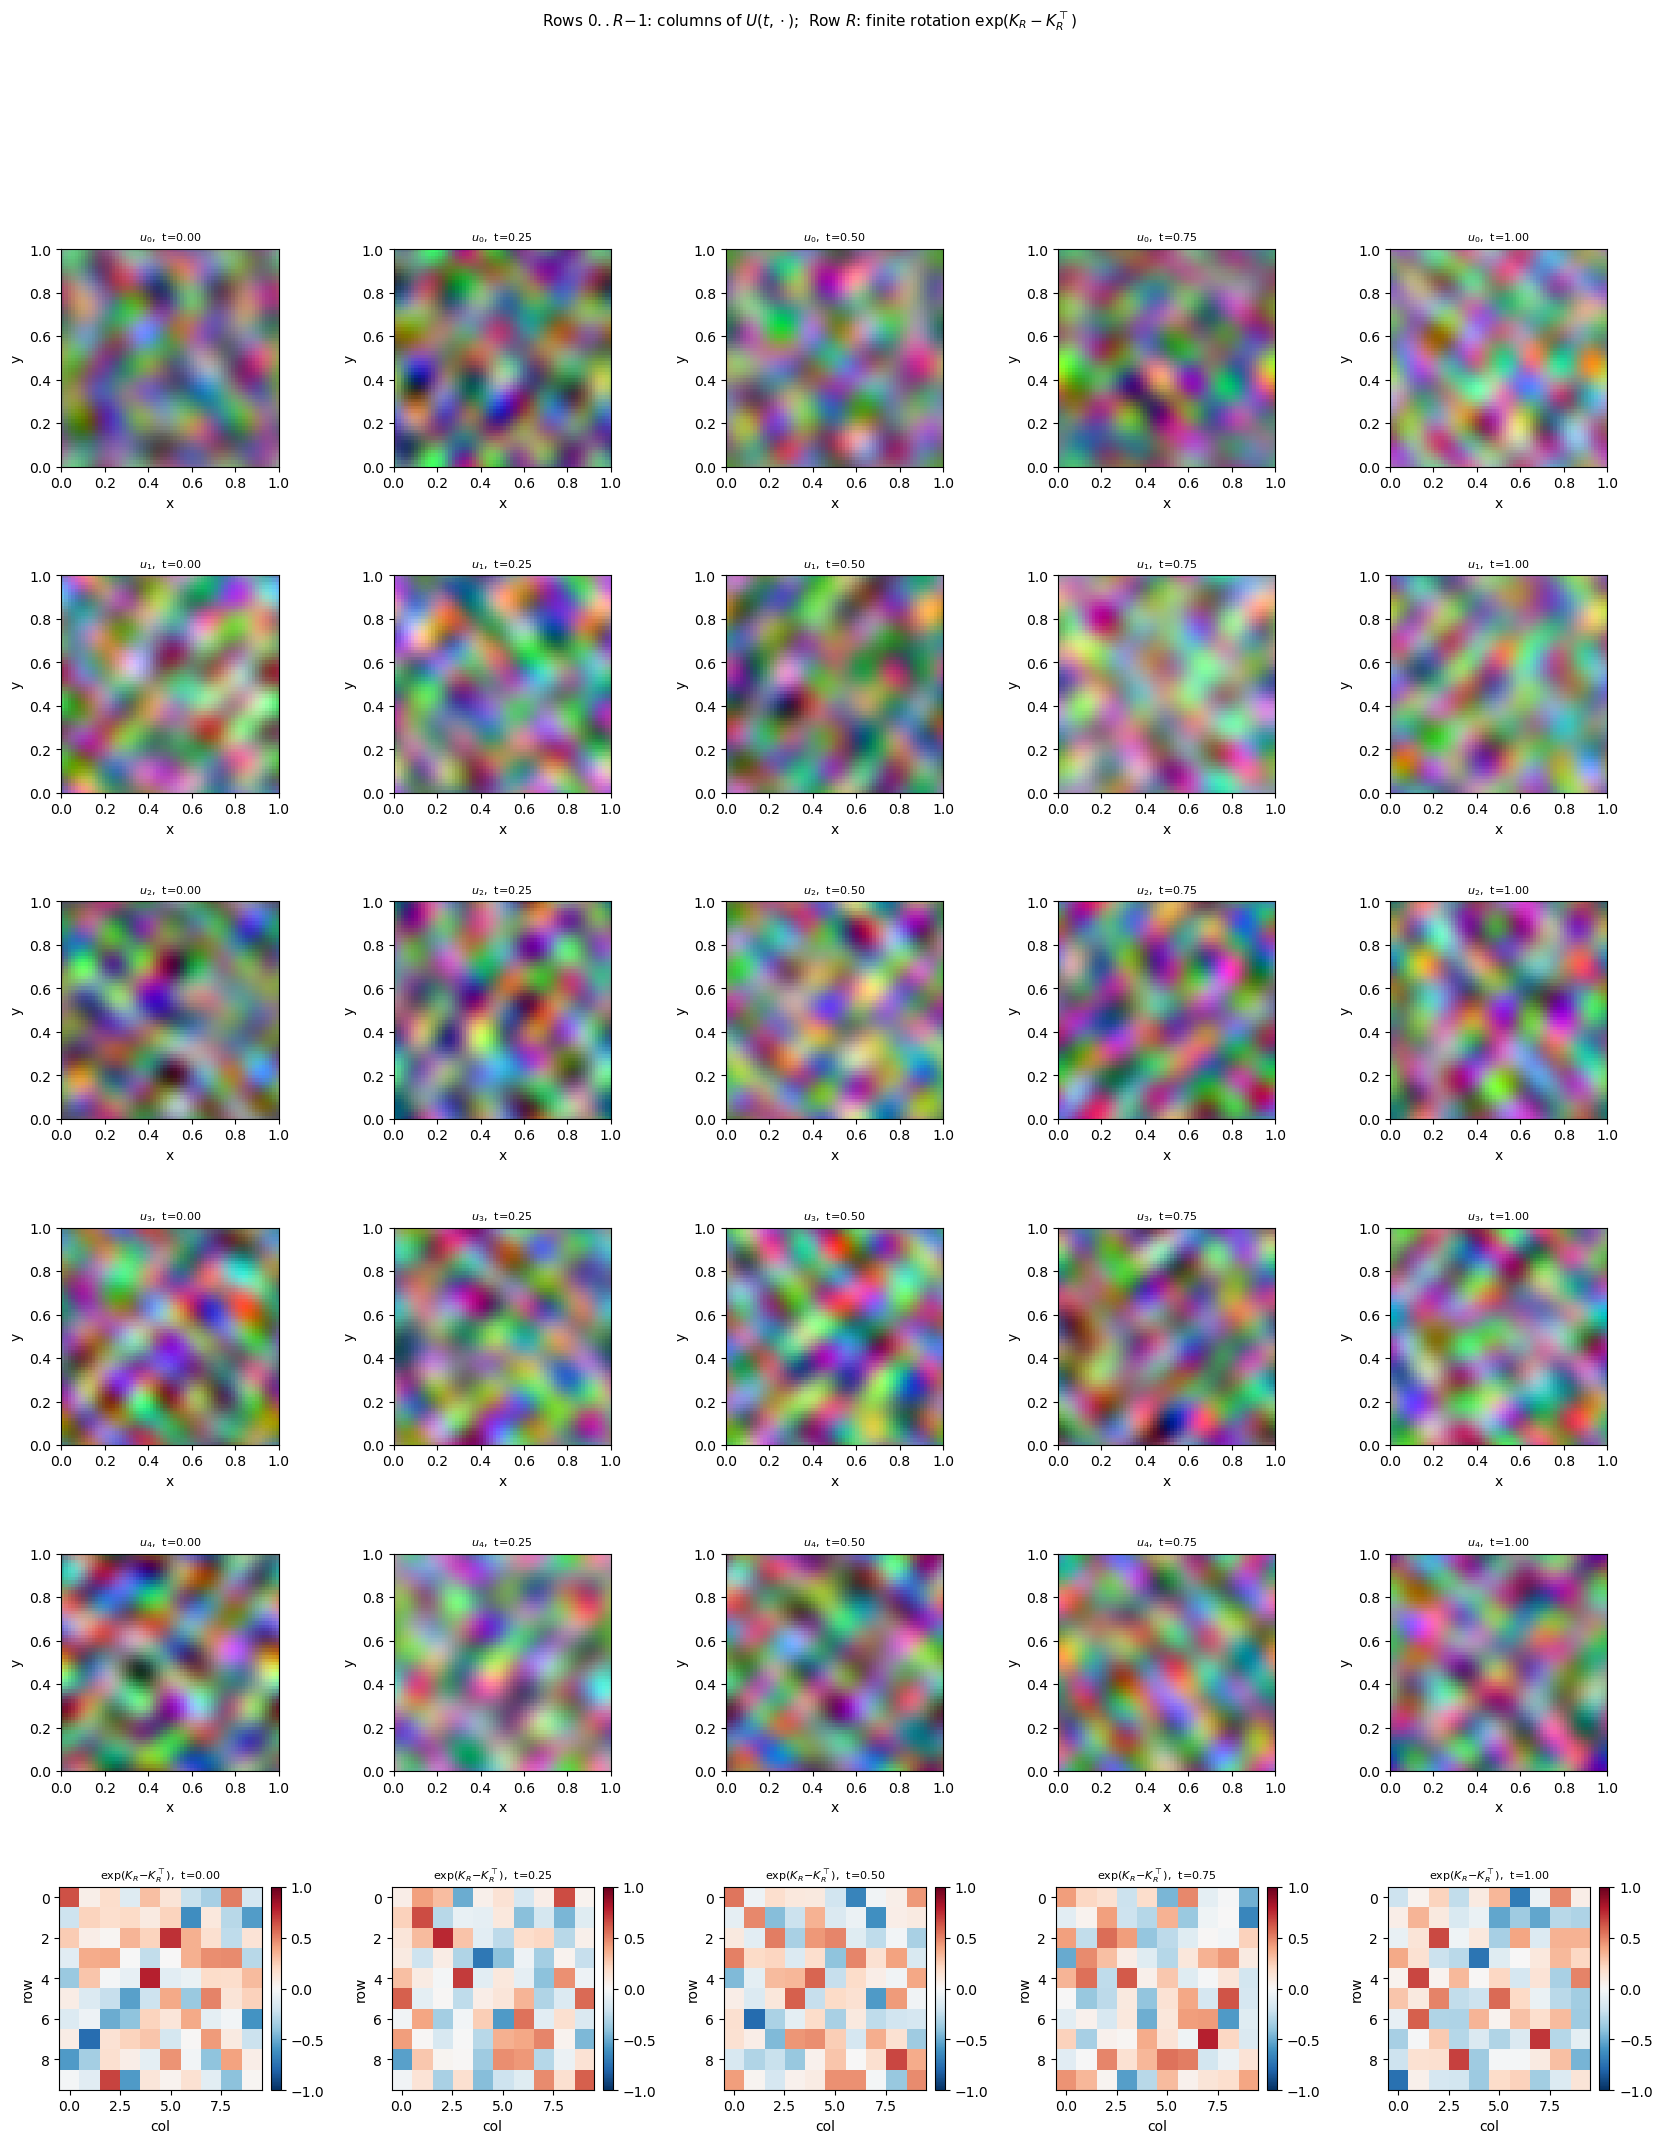

In [11]:
%autoreload 2
from infidictionary.domain_samplers import SquareSampler

N_vis_3ch = 64
coords_vis_3ch = SquareSampler(stratified=True, add_noise=False).sample(N_vis_3ch).to(device)

timesteps_3ch = torch.linspace(0.0, 1.0, 5)

visualize_generator_U(isometry_3ch, coords_vis_3ch, N_vis_3ch, timesteps_3ch, device)


### Step 4 — Pushforward / pullback round-trip (3-channel)

We apply $Q_\theta$ forward then backward and verify $Q_s^t Q_t^s f = f$.  The test functions are three specific 3-channel Fourier atoms; each row shows one function, columns show $f$, $Q_t^s f$, $Q_s^t Q_t^s f$, and the residual — displayed as RGB images.

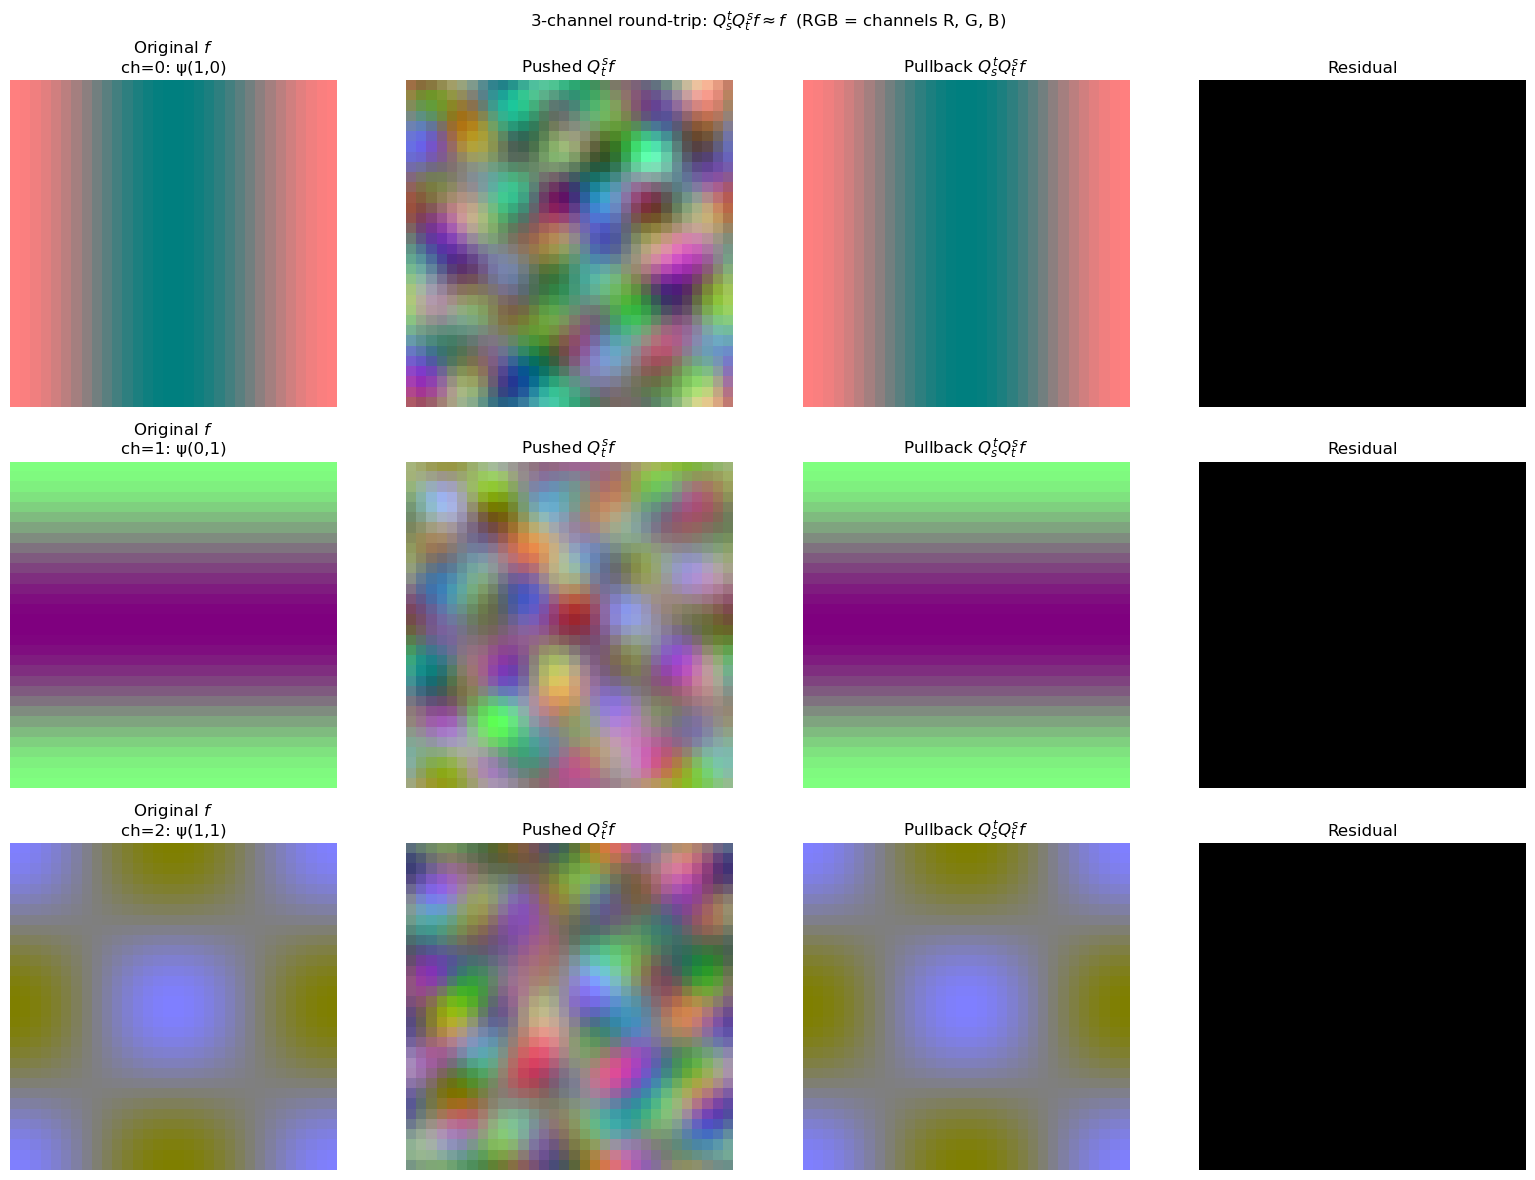

Round-trip residual ||Q_s^t Q_t^s f − f||² / ||f||²:
  ch=0: ψ(1,0): 3.56e-26
  ch=1: ψ(0,1): 3.71e-26
  ch=2: ψ(1,1): 5.23e-26


In [12]:
%autoreload 2
from infidictionary.domain_samplers import SquareSampler

start_time_3ch = 0.0
end_time_3ch   = 5.0
N_rt = 32          # grid per dim for round-trip test
inner_steps_3ch = 50

isometry_3ch.shuffle_model_state(inner_steps_3ch)
coords_rt = SquareSampler(stratified=True, add_noise=False).sample(N_rt).to(device)              # (N, 2)
lad_rt    = torch.zeros(coords_rt.shape[0], device=device)

# Pick 3 test atoms: one per output channel
test_indices = torch.tensor([
    [1,  0, 0],   # freq (1,0), channel 0
    [0,  1, 1],   # freq (0,1), channel 1
    [1,  1, 2],   # freq (1,1), channel 2
], device=device)
f3 = fourier_basis_3ch.get_atoms(coords_rt, test_indices)        # (3, N, 3)

with torch.no_grad():
    _, _, f3_pushed   = isometry_3ch.pushforward(coords_rt, lad_rt, f3,
                                                  start_time=start_time_3ch, end_time=end_time_3ch)
    _, _, f3_pullback = isometry_3ch.pullback(   coords_rt, lad_rt, f3_pushed,
                                                  start_time=start_time_3ch, end_time=end_time_3ch)

diff3 = f3_pullback - f3

col_labels = ['Original $f$', r'Pushed $Q_t^s f$', r'Pullback $Q_s^t Q_t^s f$', 'Residual']
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))

for i, (idx, label) in enumerate(zip(test_indices.tolist(),
                                      ['ch=0: ψ(1,0)', 'ch=1: ψ(0,1)', 'ch=2: ψ(1,1)'])):
    fields_row = [f3[i], f3_pushed[i], f3_pullback[i], diff3[i]]
    for j, (field, col_lbl) in enumerate(zip(fields_row, col_labels)):
        ax = axes[i, j]
        ax.imshow(to_rgb_image(field, N_rt), origin='lower', extent=[0, 1, 0, 1])
        ax.set_title(f'{col_lbl}\n{label}' if j == 0 else col_lbl)
        ax.axis('off')

plt.suptitle('3-channel round-trip: $Q_s^t Q_t^s f \\approx f$  (RGB = channels R, G, B)')
plt.tight_layout()
plt.show()

# Numerical summary
from infidictionary.utils import norm2
print("Round-trip residual ||Q_s^t Q_t^s f − f||² / ||f||²:")
for i, label in enumerate(['ch=0: ψ(1,0)', 'ch=1: ψ(0,1)', 'ch=2: ψ(1,1)']):
    rel = (norm2(diff3[i:i+1], lad_rt) / norm2(f3[i:i+1], lad_rt).clamp(min=1e-12)).item()
    print(f"  {label}: {rel:.2e}")
